In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

from sklearn import datasets

In [15]:
n_samples = 1000
n_features = 10
seed = 42

gaus_homosk_blobs = datasets.make_blobs(n_samples=n_samples,n_features=n_features, random_state=seed)

sample_X = gaus_homosk_blobs[0]

In [17]:

nc_val = 2

X_pca = PCA(n_components=nc_val).fit_transform(sample_X)
X_tsne = TSNE(n_components=nc_val, perplexity=30, random_state=0,method='barnes_hut').fit_transform(sample_X)

In [18]:
trust_pca = trustworthiness(sample_X, X_pca, n_neighbors=5)
trust_tsne = trustworthiness(sample_X, X_tsne, n_neighbors=5)

print(f"PCA trustworthiness:  {trust_pca:.4f}")
print(f"t-SNE trustworthiness: {trust_tsne:.4f}")

PCA trustworthiness:  0.8906
t-SNE trustworthiness: 0.9776


In [19]:
k = 3  # or any number based on your domain or elbow method
labels_pca = KMeans(n_clusters=k, random_state=0).fit_predict(X_pca)
labels_tsne = KMeans(n_clusters=k, random_state=0).fit_predict(X_tsne)


In [20]:
ari = adjusted_rand_score(labels_pca, labels_tsne)
nmi = normalized_mutual_info_score(labels_pca, labels_tsne)

In [22]:
nmi

1.0

In [21]:
ari

1.0

In [ ]:

num_comps = [2]
pca_vec = []
tsne_vec = []

for nc_val in num_comps:

    X_pca = PCA(n_components=nc_val).fit_transform(sample_X)
    X_tsne = TSNE(n_components=nc_val, perplexity=30, random_state=0,method='exact').fit_transform(sample_X)

    k = 5  # or any number based on your domain or elbow method
    labels_pca = KMeans(n_clusters=k, random_state=0).fit_predict(X_pca)
    labels_tsne = KMeans(n_clusters=k, random_state=0).fit_predict(X_tsne)

    score_pca = silhouette_score(X_pca, labels_pca)
    score_tsne = silhouette_score(X_tsne, labels_tsne)

    pca_vec.append(score_pca)
    tsne_vec.append(score_tsne)

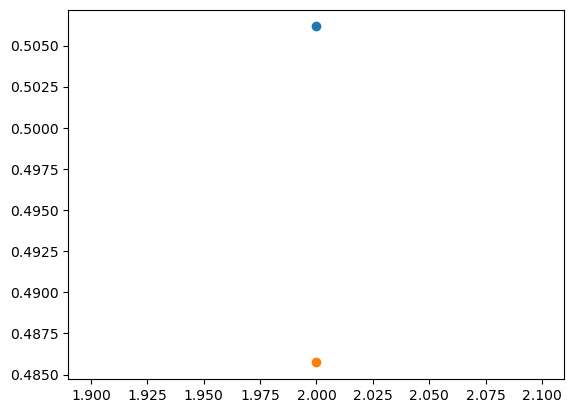

In [ ]:
from matplotlib import pyplot as plt
plt.scatter(num_comps,pca_vec)
plt.scatter(num_comps,tsne_vec)